In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib
import matplotlib.animation as animation
import matplotlib.pyplot as plt
from IPython.display import HTML
import PIL.Image

from dm_control import mjcf
from dm_control import viewer

from swarmbots.unit import Unit
from swarmbots.rendering import display_video

4 [0. 0. 0. 0.]


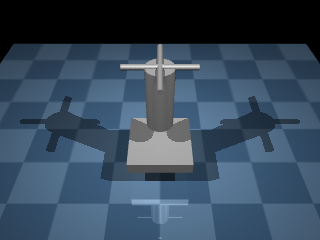

In [10]:
env = mjcf.RootElement()

chequered = env.asset.add('texture', type='2d', builtin='checker', width=300,
                            height=300, rgb1=[.2, .3, .4], rgb2=[.3, .4, .5])
grid = env.asset.add('material', name='grid', texture=chequered,
                       texrepeat=[5, 5], reflectance=.2)
env.worldbody.add('geom', type='plane', size=[2, 2, .1], material=grid)

for x in [-2, 2]:
  env.worldbody.add('light', pos=[x, -1, 3], dir=[-x, 1, -2])

unit1 = mjcf.RootElement()
unit1.compiler.angle = 'radian'

body = unit1.worldbody.add('body')
body.add('geom', type='box', size=[0.25, 0.05, 0.25])

appendage = body.add('body', pos=[0, -0.25, 0])
appendage.add('geom',  type='cylinder', fromto=[0, 0, 0, 0, -0.5, 0], size=[0.1])
appendage.add('geom', type='cylinder', fromto=[-0.25, -0.5, 0, 0.25, -0.5, 0], size=[0.02])
appendage.add('geom', type='cylinder', fromto=[0, -0.5, -0.25, 0, -0.5, 0.25], size=[0.02])
# appendage.add('joint', type='ball', range=[0, 0])#, range=[0, np.pi/2])
hinge1 = appendage.add('joint', type='hinge', axis=[0, 0, 1], range=[-np.pi/3, np.pi/3])
hinge2 = appendage.add('joint', type='hinge', axis=[1, 0, 0], range=[-np.pi/3, np.pi/3])
unit1.actuator.add('motor', joint=hinge1)
unit1.actuator.add('motor', joint=hinge2)

# spawn_site = env.worldbody.add('site', pos=[0, 0, 5], euler=[np.pi/2, 0, 0]) #, euler=[0, np.pi, 0])#, zaxis=[-np.sqrt(2/9), np.sqrt(2/3), -1/3])#euler=[0, np.pi, np.pi/2])
spawn_site = env.worldbody.add('site', pos=[0, 0, 0.25], euler=[-np.pi/2 - 0.0, 0, 0])
unit1 = spawn_site.attach(unit1) #.add('freejoint')
unit1.add('joint', type='slide', axis=[0, 0, 1], name='s1')
unit1.add('joint', type='slide', axis=[1, 0, 0], name='s2')

cam = env.worldbody.add('camera', mode='targetbody', target=appendage, pos=[0, 1.5, 1])

physics = mjcf.Physics.from_mjcf_model(env)

print(physics.data.qvel.size, physics.data.qvel)
PIL.Image.fromarray(physics.render(camera_id=-1))

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x))  # Use tanh activation for continuous actions
        return x    


def select_action(policy, state):
    with torch.no_grad():
        action = policy(state)
    return action


def get_state(physics):
    return np.concatenate([physics.data.qpos, physics.data.qvel])


def apply_action(physics, action):
    physics.data.ctrl[:] = action * 100


def calc_reward(physics):
    qpos = physics.data.qpos[:-2]
    
    reward = -np.sum((qpos + np.sign(qpos)) ** 2 - 1)
    
    if reward < -0.15:
        return reward * 100, True
    
    return reward, False


def reinforce(physics, policy, optimizer, num_episodes, gamma, max_duration=10.0):
    for episode in range(num_episodes):
        physics.reset()
        done = False
        
        log_prob_actions = []
        rewards = []
        
        actions = []
        
        while not done and physics.data.time < max_duration:
            state = torch.FloatTensor(get_state(physics))
            action_mean = policy(state)
            action_std = torch.FloatTensor([0.1, 0.1])  # You can adjust the standard deviation as needed
            action_distribution = torch.distributions.Normal(action_mean, action_std)
            
            action = action_distribution.sample()
            log_prob_action = action_distribution.log_prob(action)
            
            log_prob_actions.append(log_prob_action)
            
            apply_action(physics, action)
            
            physics.step(nstep=1)
            
            reward, done = calc_reward(physics)
            rewards.append(reward)
            
            actions.append(action_mean.detach().numpy())
        
        # Compute the discounted rewards
        returns = []
        running_add = 0
        for r in rewards[::-1]:
            running_add = r + gamma * running_add
            returns.append(running_add)
        returns = torch.tensor(returns[::-1])
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        
        # Calculate loss and update policy
        policy_loss = torch.sum(torch.stack(log_prob_actions) * returns.unsqueeze(1))
        
        policy_loss.retain_grad()
        
        optimizer.zero_grad()
        print(policy_loss.backward()
        optimizer.step()
        
        print(policy_loss.grad.min(), policy_loss.grad.max())

        # Print episode information
        if ((episode + 1) % 50) == 0:
            print(f"Episode {episode + 1}, Total Reward: {sum(rewards)}")
            print(np.stack(actions).mean(axis=0), np.stack(actions).std(axis=0))


policy_net = PolicyNetwork(8, 64, 2)
optimizer = optim.Adam(policy_net.parameters(), lr=1e-2)

reinforce(physics, policy_net, optimizer, 10000, 0.5)


tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1., dtype=torch.float64)
tensor(1., dtype=torch.float64) tensor(1


KeyboardInterrupt



In [11]:
duration = 5   # (Seconds)
framerate = 30  # (Hz)
video = []
 
last_switch = 0


physics.reset()

while physics.data.time < duration:
    state = torch.FloatTensor(get_state(physics))
    action_mean = policy_net(state)
    apply_action(physics, action_mean.detach().numpy())
    
    
    physics.step()

    if len(video) < physics.data.time * framerate:
        
        pixels = physics.render(camera_id=-1)
        video.append(pixels.copy())
    
 

display_video(video, framerate)


KeyboardInterrupt



In [43]:
physics.data.qpos

array([-0.09289103,  0.04479791, -1.04770075, -1.04769955])

In [122]:
np.concatenate([physics.data.qpos, physics.data.qvel])

array([-0.02168953, -0.03073212,  0.38963361, -0.20229654,  0.22114658,
        0.18125404, -1.93815623,  2.08265143])